In [4]:
import pyrealsense2 as rs
import copy
import os
import pathlib
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from pydrake.geometry import (
    ClippingRange,
    ColorRenderCamera,
    DepthRange,
    DepthRenderCamera,
    MakeRenderEngineVtk,
    RenderCameraCore,
    RenderEngineVtkParams,
    RenderLabel,
    
    Role,
    StartMeshcat,
)
from pydrake.perception import DepthImageToPointCloud
from pydrake.math import RigidTransform, RollPitchYaw
from pydrake.multibody.parsing import Parser
from pydrake.multibody.plant import AddMultibodyPlantSceneGraph
from pydrake.multibody.tree import BodyIndex
from pydrake.systems.analysis import Simulator
from pydrake.systems.framework import DiagramBuilder
from pydrake.systems.sensors import (
    CameraInfo,
    RgbdSensor,
)
from pydrake.visualization import (
    AddDefaultVisualization,
    
    ColorizeDepthImage,
    ColorizeLabelImage,
)
import pydrake.geometry as pydgeo
from pydrake.all import (
    UnitInertia,
    SpatialInertia,
    MeshcatPointCloudVisualizer,
    LeafSystem,
    FixedOffsetFrame,
    AbstractValue, BaseField,PixelType,LightParameter,Rgba, DrakeLcm, LcmSubscriberSystem,LcmImageArrayToImages,LcmInterfaceSystem,Value,PointCloud,ImageDepth16U,ImageDepth32F,ImageToLcmImageArrayT,LcmPublisherSystem,ImageRgba8U,Image
)
# from diff_co_mpc.diff_co_lcm import lcmt_pose
import time
from drake import lcmt_robot_state, lcmt_point_cloud, lcmt_image, lcmt_image_array
import copy
import utils

import cv2
# try:
#     meshcat
#     print("meshcat already defined")
# except NameError:
#     meshcat = StartMeshcat()

TEMP_FOLDER = pathlib.Path(os.getcwd())/ '..' / '..' / 'temp'
TEMP_FOLDER.mkdir(exist_ok=True)
CODEGEN_FOLDER = TEMP_FOLDER / 'codegen'
CODEGEN_FOLDER.mkdir(exist_ok=True,parents=True)
# from diff_co_mpc.plant import plant_from_yaml
import sys

sys.path += [".."]


In [12]:
import pyrealsense2 as rs

from pydrake.all import ConvertDepth16UTo32F,RotationMatrix
from dt_apriltags import Detector
class RealsenseReader(LeafSystem):
    def __init__(self, ):
        super().__init__()
        
        self.depth_image_1_output_port = self.DeclareAbstractOutputPort(
            name="out_1",
            alloc=lambda: Value(ImageDepth32F()),
            
            calc=self.get_depth_1)
        self.init_realsense()
        self.points = np.zeros((0,3))
        self.april_tag_detector = Detector(searchpath=['apriltags'],
                       families='tag36h11',
                       nthreads=1,
                       quad_decimate=1.0,
                       quad_sigma=0.0,
                       refine_edges=1,
                       decode_sharpening=0.25,
                       debug=0)
        self.transform_output_port = self.DeclareAbstractOutputPort(
            name="camera_transform_out",
            alloc=lambda: Value(RigidTransform()),
            calc=self.calc_transform)
        self.tag = None
# # plt.colorbar()
# from dt_apriltags import Detector
# # cv2
# at_detector = Detector(searchpath=['apriltags'],
#                        families='tag36h11',
#                        nthreads=1,
#                        quad_decimate=1.0,
#                        quad_sigma=0.0,
#                        refine_edges=1,
#                        decode_sharpening=0.25,
#                        debug=0)
# cv2.cvtColor(realsense_reader.color_image, cv2.COLOR_BGR2GRAY)
# camera_params = ( realsense_reader.camera_1_drake_info.focal_x(), realsense_reader.camera_1_drake_info.focal_y(), realsense_reader.camera_1_drake_info.center_x(), realsense_reader.camera_1_drake_info.center_y() )
# tag_size = 0.06
# tags = at_detector.detect(cv2.cvtColor(realsense_reader.color_image, cv2.COLOR_BGR2GRAY), estimate_tag_pose=True, camera_params=camera_params, tag_size=tag_size)
# tag.pose_R
# tag.pose_t
    def calc_transform(self,context,output):
        if self.tag is None:
            return
        R = self.tag.pose_R
        t = self.tag.pose_t

        correction = RotationMatrix.MakeXRotation(np.pi).matrix()
        t_c = np.array([0,0,0.05])
#         correction = np.array( [
#     [1,0,0],
#     [0,0,-1],
#     [0,-1,0.],
# ]
#          ).T
        pose = np.eye(4)
        # pose[:3,:3] = correction@R
        # pose[:3,3:] = correction@t
        pose[:3,:3] = R
        pose[:3,3:] = t
        pose = np.linalg.inv(pose)
        pose[:3,:3] = correction@pose[:3,:3]
        pose[:3,3:] = correction@pose[:3,3:] + t_c.reshape(3,1)
        # pose = RotationMatrix.MakeXRotation(np.pi/2).matrix()

        output.set_value(RigidTransform(pose)) 
    def init_realsense(self):
        camera_1_serial = "046122251075"
        camera_1_serial = "046122251304"
        pipeline_1 = rs.pipeline()
        config_1 = rs.config()
        config_1.enable_device(camera_1_serial)
        config_1.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
        # config_1.enable_stream(rs.stream.color, 640, 480, rs.format.y16, 30) #grayscale
        config_1.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
        pipeline_1.start(config_1)
        profile = pipeline_1.get_active_profile()
        depth_intrinsics = profile.get_stream(rs.stream.depth).as_video_stream_profile().get_intrinsics()
        focal_x = depth_intrinsics.fx
        focal_y = depth_intrinsics.fy
        width,  height = depth_intrinsics.width,depth_intrinsics.height
        center_x, center_y = depth_intrinsics.ppx, depth_intrinsics.ppy
        self.depth_camera_1_drake_info = CameraInfo(width,  height,focal_x,focal_y,center_x, center_y)

        color_intrinsics = profile.get_stream(rs.stream.color).as_video_stream_profile().get_intrinsics()
        focal_x = color_intrinsics.fx
        focal_y = color_intrinsics.fy
        width,  height = color_intrinsics.width,color_intrinsics.height
        center_x, center_y = color_intrinsics.ppx, color_intrinsics.ppy
        self.color_camera_1_drake_info = CameraInfo(width,  height,focal_x,focal_y,center_x, center_y)
        # width, height
        self.camera_1_params_at = ( self.color_camera_1_drake_info.focal_x(), self.color_camera_1_drake_info.focal_y(), self.color_camera_1_drake_info.center_x(), self.color_camera_1_drake_info.center_y() )
        self.tag_size = 0.061
        self.pipeline_1 = pipeline_1
        self.config_1 = config_1

    def stop(self):
        self.pipeline_1.stop()
    def get_depth_1(self, context, output):
        frame_received, frame = self.pipeline_1.try_wait_for_frames(10)
        if frame_received:
            # depth_image = np.asanyarray(depth_frame.get_data()).copy()
            depth_frame = frame.get_depth_frame()
            width = depth_frame.width
            height = depth_frame.height
            pc = rs.pointcloud()
            self.points = pc.calculate(depth_frame)
            self.points = np.asanyarray(pc.calculate(depth_frame).get_vertices()).view(dtype=np.float32).reshape(-1,3)
            self.pc = pc
            image_= ImageDepth16U(width,height)
            image_.mutable_data[:] = np.frombuffer(depth_frame.get_data(),dtype=np.uint16).reshape(height,width,1)
            image_32F = ImageDepth32F(width,height)
            image_ = ConvertDepth16UTo32F(image_,image_32F)
            output.set_value(image_32F)
            color_frame = frame.get_color_frame()
            self.color_image = np.asanyarray(color_frame.get_data())
            # if self.tag is None:
            try:
                tags = self.april_tag_detector.detect(cv2.cvtColor(self.color_image, cv2.COLOR_BGR2GRAY), estimate_tag_pose=True, camera_params=self.camera_1_params_at, tag_size=self.tag_size)
                self.tag = tags[0]
            except:
                pass

In [1]:
import pyrealsense2 as rs
camera_1_serial = "046122251304"
pipeline_1 = rs.pipeline()
config_1 = rs.config()
config_1.enable_device(camera_1_serial)
config_1.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
# config_1.enable_stream(rs.stream.color, 640, 480, rs.format.y16, 30) #grayscale
config_1.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)


camera_2_serial = "046122251075"
pipeline_2 = rs.pipeline()
config_2 = rs.config()
config_2.enable_device(camera_2_serial)
config_2.enable_stream(rs.stream.color, 640, 480, rs.format.bgr8, 30)
# config_2.enable_stream(rs.stream.color, 640, 480, rs.format.y16, 30) #grayscale
config_2.enable_stream(rs.stream.depth, 640, 480, rs.format.z16, 30)
import time
pipeline_1.start(config_1)
pipeline_2.start(config_2)
print("a")
time.sleep(2)
profile = pipeline_1.get_active_profile()
profile = pipeline_2.get_active_profile()
frame_received, frame = pipeline_1.try_wait_for_frames(10)
if frame_received:
    depth_frame = frame.get_depth_frame()
    width = depth_frame.width
    height = depth_frame.height
camera_2_extrinsics = profile.get_stream(rs.stream.depth).as_video_stream_profile().get_extrinsics_to(profile.get_stream(rs.stream.color).as_video_stream_profile())
pipeline_1.stop()
pipeline_2.stop()
134

a


134

In [22]:
from multiprocessing import shared_memory
dtype = np.float32
array_shape = (480, 640, 1)
shared_memory_name = "depth_image_1"

try:
    shm = shared_memory.SharedMemory(name=shared_memory_name, create=True, size=np.prod(array_shape) * np.dtype(dtype).itemsize)
    shared_array = np.ndarray(array_shape, dtype=dtype, buffer=shm.buf)
    shared_array[:] = np.nan
    print("Created new shared memory.")
except FileExistsError:
    shm = shared_memory.SharedMemory(name=shared_memory_name)
    shared_array = np.ndarray(array_shape, dtype=dtype, buffer=shm.buf)
    print("Linked to existing shared memory.")
shared_array[:] = image_32F.data

Created new shared memory.


In [10]:
from pydrake.all import ImageDepth16U,ImageDepth32F,ConvertDepth16UTo32F
import numpy as np
image_= ImageDepth16U(width,height)
image_.mutable_data[:] = np.frombuffer(depth_frame.get_data(),dtype=np.uint16).reshape(height,width,1)
image_32F = ImageDepth32F(width,height)
image_ = ConvertDepth16UTo32F(image_,image_32F)

dtype('float32')

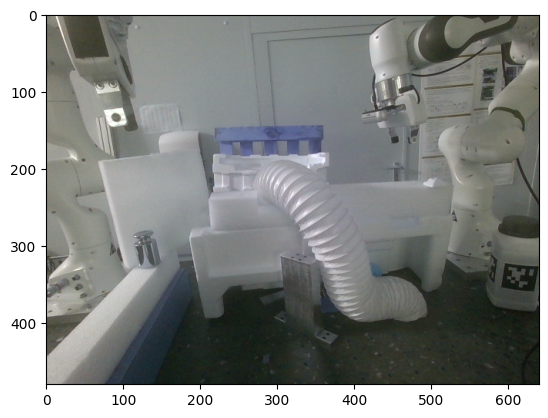

In [26]:
import matplotlib.pyplot as plt
plt.imshow(color_image)
image_32F.data.dtype

In [28]:
color_image.dtype

dtype('uint8')

In [23]:
color_frame = frame.get_color_frame()
color_image = np.asanyarray(color_frame.get_data())

In [22]:
if (len(ctx.devices) > 0):
    # ctx.
    for dev in ctx.devices:
        print ('Found device: ', \
                dev.get_info(rs.camera_info.name), ' ', \
                dev.get_info(rs.camera_info.serial_number))
        serials.append(dev.get_info(rs.camera_info.serial_number))
else:
    print("No Intel Device connected")
ctx.sensors

RuntimeError: RS4XX: RGB modules inconsistency - 2 found

In [6]:
def average_quaternions(quaternions):
    """
    Calculate average quaternion

    :params quaternions: is a Nx4 numpy matrix and contains the quaternions
        to average in the rows.
        The quaternions are arranged as (w,x,y,z), with w being the scalar

    :returns: the average quaternion of the input. Note that the signs
        of the output quaternion can be reversed, since q and -q
        describe the same orientation
    """

    # Number of quaternions to average
    samples = quaternions.shape[0]
    mat_a = np.zeros(shape=(4, 4), dtype=np.float64)

    for i in range(0, samples):
        quat = quaternions[i, :]
        # multiply quat with its transposed version quat' and add mat_a
        mat_a = np.outer(quat, quat) + mat_a

    # scale
    mat_a = (1.0/ samples)*mat_a
    # compute eigenvalues and -vectors
    eigen_values, eigen_vectors = np.linalg.eig(mat_a)
    # Sort by largest eigenvalue
    eigen_vectors = eigen_vectors[:, eigen_values.argsort()[::-1]]
    # return the real part of the largest eigenvector (has only real part)
    return np.real(np.ravel(eigen_vectors[:, 0]))  

In [14]:
from pydrake.all import ConvertDepth16UTo32F
builder = DiagramBuilder()
from dt_apriltags import Detector
# cv2
at_detector = Detector(searchpath=['apriltags'],
                       families='tag36h11',
                       nthreads=1,
                       quad_decimate=1.0,
                       quad_sigma=0.0,
                       refine_edges=1,
                       decode_sharpening=0.25,
                       debug=0)
lcm = DrakeLcm()
lcm_sys = builder.AddSystem(LcmInterfaceSystem(lcm))
realsense_reader = builder.AddSystem(RealsenseReader())
depth_to_point_cloud_1 = builder.AddSystem(DepthImageToPointCloud(camera_info=realsense_reader.depth_camera_1_drake_info, fields= BaseField.kXYZs, pixel_type=PixelType.kDepth32F))

builder.Connect(realsense_reader.depth_image_1_output_port,depth_to_point_cloud_1.depth_image_input_port())
# depth_to_point_cloud_2 = builder.AddSystem(DepthImageToPointCloud(camera_info=realsense_intrinsics, fields= BaseField.kXYZs, pixel_type=PixelType.kDepth32F))
builder.Connect(realsense_reader.transform_output_port,depth_to_point_cloud_1.camera_pose_input_port())

diag = builder.Build()
diagram_context = diag.CreateDefaultContext()

# lcm_to_images_context = lcm_to_images.GetMyMutableContextFromRoot(diagram_context)
from pydrake.all import Simulator
# https://github.com/RobotLocomotion/drake/blob/master/bindings/pydrake/systems/test/lcm_test.py
simulator = Simulator(diag,diagram_context)
depth_to_point_cloud_1_context = depth_to_point_cloud_1.GetMyContextFromRoot(diagram_context)
realsense_reader_context = realsense_reader.GetMyContextFromRoot(diagram_context)
dt = 0.1
iteration = 0

tag_size = 0.061
positions = []
quaternions = []
i = 0
try:
    while True:
        time.sleep(dt)
        simulator.AdvanceTo(0.000001)
        diag.ForcedPublish(diagram_context)
        point_cloud = depth_to_point_cloud_1.point_cloud_output_port().Eval(depth_to_point_cloud_1_context)
        point_cloud = point_cloud#.Crop([-1,-0.4,0.00],[1,1,2])
        try:
            camera_params = ( realsense_reader.color_camera_1_drake_info.focal_x(), realsense_reader.color_camera_1_drake_info.focal_y(), realsense_reader.color_camera_1_drake_info.center_x(), realsense_reader.color_camera_1_drake_info.center_y() )
            tags = at_detector.detect(cv2.cvtColor(realsense_reader.color_image, cv2.COLOR_BGR2GRAY), estimate_tag_pose=True, camera_params=camera_params, tag_size=tag_size)
            positions.append(tags[0].pose_t.squeeze())
            quaternions.append(RotationMatrix(tags[0].pose_R).ToQuaternion().wxyz())
            print("got",len(positions), "tags")
        except:
            pass
        depth_image = realsense_reader.depth_image_1_output_port.Eval(realsense_reader_context)
        points = realsense_reader.points
        point_cloud = PointCloud(points.shape[0])
        point_cloud.mutable_xyzs()[:] = points.T
        # meshcat.SetObject("/point_cloud", point_cloud,0.001,Rgba(1,0,0,1))
        time.sleep(0.2)
        # try:
        #     # plt.imshow(realsense_reader.color_image)
        #     # plt.show()
        # except:
        #     pass
        # meshcat.SetObject("/point_cloud", depth_to_point_cloud_1.point_cloud_output_port().Eval(depth_to_point_cloud_1_context))
    # print(np.asarray(p.camera_pose_lcm_output_port_2.Eval(p_context).pose).reshape(4,4))
    # p.visualizer.ForcedPublish(p.visualizer.GetMyContextFromRoot(p.context))
    # meshcat.SetObject("/point_cloud", pc)
except KeyboardInterrupt:
    pass
finally:
    realsense_reader.stop()

# lcm.unsubscribe(subscription)

got 1 tags
got 2 tags
got 3 tags
got 4 tags
got 5 tags
got 6 tags
got 7 tags
got 8 tags
got 9 tags
got 10 tags
got 11 tags
got 12 tags
got 13 tags
got 14 tags
got 15 tags
got 16 tags
got 17 tags
got 18 tags
got 19 tags
got 20 tags
got 21 tags
got 22 tags
got 23 tags
got 24 tags
got 25 tags
got 26 tags
got 27 tags
got 28 tags
got 29 tags
got 30 tags
got 31 tags
got 32 tags
got 33 tags
got 34 tags
got 35 tags
got 36 tags
got 37 tags
got 38 tags
got 39 tags
got 40 tags
got 41 tags
got 42 tags
got 43 tags
got 44 tags
got 45 tags
got 46 tags
got 47 tags
got 48 tags
got 49 tags
got 50 tags
got 51 tags
got 52 tags
got 53 tags
got 54 tags
got 55 tags
got 56 tags
got 57 tags
got 58 tags
got 59 tags
got 60 tags
got 61 tags
got 62 tags
got 63 tags
got 64 tags
got 65 tags
got 66 tags
got 67 tags
got 68 tags
got 69 tags
got 70 tags
got 71 tags
got 72 tags
got 73 tags
got 74 tags
got 75 tags
got 76 tags
got 77 tags
got 78 tags
got 79 tags
got 80 tags
got 81 tags
got 82 tags
got 83 tags
got 84 tags


In [16]:
# from scipy.spatial.transform clear_output(wait=True)
# import Rotation as scipy_R
from scipy.spatial.transform import Rotation as scipy_R

quaternions = np.vstack(quaternions,)[:]
positions = np.vstack(positions,).reshape(-1,3)[:]
t = np.mean(positions,axis=0).reshape(3,1)
q = average_quaternions(quaternions)
R = scipy_R.from_quat([*q[1:],q[0]]).as_matrix()
pose = np.eye(4)
pose[:3,:3] = R
pose[:3,3:] = t
final_apriltag_pose = RigidTransform(pose)

In [ ]:
positions

array([], shape=(0, 3), dtype=float64)

In [17]:
final_apriltag_pose.GetAsMatrix34()@np.array([0,1,0,1]).reshape(4,1)
final_apriltag_pose.GetAsMatrix4()

array([[ 0.99516671,  0.07074268,  0.06810796,  0.07231502],
       [-0.08373974,  0.24908092,  0.96485561,  0.25031985],
       [ 0.05129208, -0.96589553,  0.25380101,  0.81090267],
       [ 0.        ,  0.        ,  0.        ,  1.        ]])

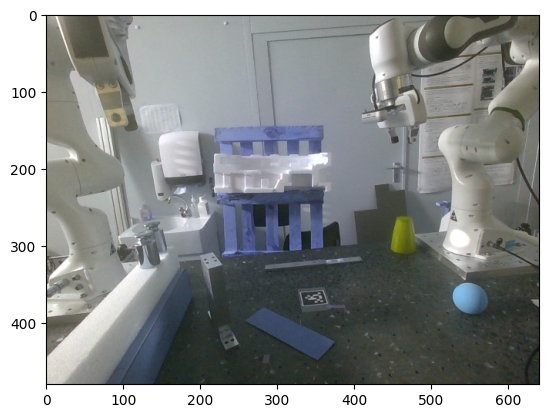

In [18]:
plt.imshow(realsense_reader.color_image)

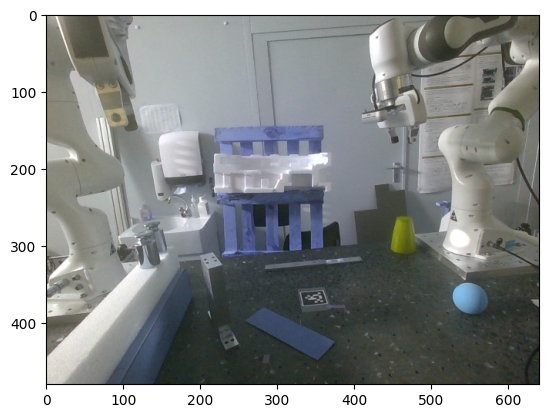

In [19]:
plt.imshow(realsense_reader.color_image)
# plt.colorbar()
from dt_apriltags import Detector
# cv2
at_detector = Detector(searchpath=['apriltags'],
                       families='tag36h11',
                       nthreads=1,
                       quad_decimate=1.0,
                       quad_sigma=0.0,
                       refine_edges=1,
                       decode_sharpening=0.25,
                       debug=0)
cv2.cvtColor(realsense_reader.color_image, cv2.COLOR_BGR2GRAY)
camera_params = ( realsense_reader.color_camera_1_drake_info.focal_x(), realsense_reader.color_camera_1_drake_info.focal_y(), realsense_reader.color_camera_1_drake_info.center_x(), realsense_reader.color_camera_1_drake_info.center_y() )
tag_size = 0.06
tags = at_detector.detect(cv2.cvtColor(realsense_reader.color_image, cv2.COLOR_BGR2GRAY), estimate_tag_pose=True, camera_params=camera_params, tag_size=tag_size)
# tag.pose_R
# tag.pose_t
# cv2.cvtColor(realsense_reader.color_image, cv2.COLOR_BGR2GRAY).shape

In [ ]:

realsense_reader.depth_camera_1_drake_info.focal_x(), realsense_reader.depth_camera_1_drake_info.focal_y(), realsense_reader.depth_camera_1_drake_info.center_x(), realsense_reader.depth_camera_1_drake_info.center_y() 

(386.07855224609375, 386.07855224609375, 319.1185607910156, 238.21234130859375)

In [ ]:
camera_params

(383.9413757324219, 382.9921569824219, 313.0089111328125, 250.05235290527344)

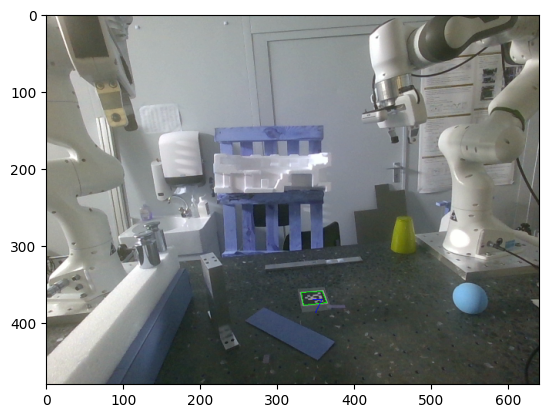

: 

In [20]:
color_image = realsense_reader.color_image.copy()
for tag in tags:
    for idx in range(len(tag.corners)):
        cv2.line(color_image, tuple(tag.corners[idx-1, :].astype(int)), tuple(tag.corners[idx, :].astype(int)), (0, 255, 0))

    cv2.putText(color_image, str(tag.tag_id+1),
                org=(tag.corners[0, 0].astype(int)+10,tag.corners[0, 1].astype(int)+10),
                fontFace=cv2.FONT_HERSHEY_SIMPLEX,
                fontScale=0.8,
                color=(0, 0, 255))
    


plt.imshow(color_image)

In [ ]:
tag

            

Detection object:
tag_family = b'tag36h11'
tag_id = 6
hamming = 0
decision_margin = 60.5185432434082
homography = [[ 9.42248165e-02 -1.83469388e+01  3.75650136e+02]
 [ 1.72439017e+01 -2.08892393e+00  1.88564321e+02]
 [ 3.27081642e-03 -5.98019626e-03  1.00000000e+00]]
center = [375.65013566 188.56432064]
corners = [[360.54437256 170.81167603]
 [358.36837769 204.27275085]
 [390.47897339 205.99151611]
 [392.83850098 172.94078064]]
pose_R = [[-0.0528336  -0.99202982 -0.11439163]
 [ 0.99461163 -0.04204392 -0.09476294]
 [ 0.08919819 -0.11878192  0.98890573]]
pose_t = [[ 0.11941966]
 [-0.09702178]
 [ 0.6968445 ]]
pose_err = 5.992762398316396e-09

In [ ]:
# np.asanyarray(realsense_reader.points.get_data(),dtype=np.float32).reshape(-1,3)
pc_data = np.asanyarray(realsense_reader.points.get_vertices()).view(dtype=np.float32).reshape(-1,3)
point_cloud = PointCloud(pc_data.shape[0])
point_cloud.mutable_xyzs()[:] = pc_data.T
meshcat.SetObject("/point_cloud", point_cloud)

In [ ]:
point_cloud.mutable_xyzs

In [ ]:
plt.imshow(depth_image.data.squeeze())

In [ ]:
point_cloud.xyzs().min()